# Notebook 2: EDA y Preparación de Datos

**Objetivo:** analizar la calidad y cobertura del dataset del S&P 500,
construir el calendario de rebalanceo y el universo elegible de activos
para el backtest de la estrategia momentum.

**Inputs (de NB1):**
- `closes.parquet` — precios close wide (date × tickers)
- `opens.parquet` — precios open wide
- `sp500_membership.parquet` — indicador de pertenencia 1/0
- `spy.parquet` — benchmark SPY (open + close)
- `sp500_history.parquet` — dataset fuente en formato long (incluye `security_name` y `volume`)

**Outputs:**
- `closes.parquet` / `opens.parquet` / `sp500_membership.parquet` — re-exportados tras limpieza de duplicados
- `rebalance_dates.csv` — fechas de rebalanceo (último día hábil de cada mes)
- `eligible_universe.parquet` — universo elegible por fecha de rebalanceo (wide, 1/0)
- `share_class_log.csv` — log de tickers eliminados por duplicidad en cada fecha de rebalanceo

## 0) Imports y carga de datos

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

# ── Rutas ──
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

# ── Cargar parquets de NB1 ──
closes = pd.read_parquet(DATA_DIR / "closes.parquet")
opens = pd.read_parquet(DATA_DIR / "opens.parquet")
membership = pd.read_parquet(DATA_DIR / "sp500_membership.parquet")
spy = pd.read_parquet(DATA_DIR / "spy.parquet")

print(f"closes:     {closes.shape}")
print(f"opens:      {opens.shape}")
print(f"membership: {membership.shape}")
print(f"spy:        {spy.shape}")

closes:     (9087, 1289)
opens:      (9087, 1289)
membership: (9087, 1289)
spy:        (8327, 2)


## 1) Clase DataQualityAnalyzer

Encapsula el análisis de calidad y cobertura del dataset.

In [2]:
class DataQualityAnalyzer:
    """Analiza calidad y cobertura de los datos wide del S&P 500."""

    def __init__(self, closes, opens, membership):
        self.closes = closes
        self.opens = opens
        self.membership = membership

    # ── Resumen general ──
    def summary(self):
        """Imprime estadísticas generales del dataset."""
        print("═" * 60)
        print("RESUMEN DEL DATASET")
        print("═" * 60)
        print(f"Rango de fechas:  {self.closes.index.min().date()} → "
              f"{self.closes.index.max().date()}")
        print(f"Días de trading:  {len(self.closes.index):,}")
        print(f"Tickers totales:  {self.closes.shape[1]:,}")
        print(f"% NaN en closes:  {self.closes.isna().mean().mean() * 100:.1f}%")
        print(f"% NaN en opens:   {self.opens.isna().mean().mean() * 100:.1f}%")

    # ── Tabla de tickers por pertenencia ──
    def ticker_membership_table(self):
        """Clasifica tickers según su pertenencia histórica al S&P 500."""
        ever_in = (self.membership.max() == 1).sum()
        never_in = (self.membership.max() == 0).sum()
        total = self.membership.shape[1]
        table = pd.DataFrame({
            "Categoría": ["Total tickers", "Alguna vez in_sp500=1",
                          "Nunca in_sp500=1"],
            "Cantidad": [total, ever_in, never_in],
        })
        return table

    # ── Activos con in_sp500=1 por mes ──
    def membership_over_time(self):
        """Nº de activos con in_sp500=1 por mes."""
        monthly = self.membership.resample("ME").last()
        return monthly.sum(axis=1).rename("n_in_sp500")

    # ── Cobertura total por mes ──
    def coverage_over_time(self):
        """Nº de activos con datos (non-NaN) por mes."""
        monthly = self.closes.resample("ME").last()
        return monthly.notna().sum(axis=1).rename("n_with_data")

    # ── Gap analysis: membership=1 pero sin precio ──
    def gap_analysis(self, top_n=10):
        """Detecta y cuantifica huecos donde in_sp500=1 pero close es NaN."""
        mask_in = self.membership == 1
        mask_nan = self.closes.isna()
        gaps = mask_in & mask_nan

        total_gaps = gaps.sum().sum()
        total_in = mask_in.sum().sum()
        pct = total_gaps / total_in * 100 if total_in > 0 else 0

        print(f"Total gaps (in_sp500=1 & precio NaN): {total_gaps:,}")
        print(f"Total observaciones in_sp500=1:       {total_in:,}")
        print(f"Porcentaje de gaps:                   {pct:.4f}%")

        # Top tickers con más gaps
        gaps_per_ticker = gaps.sum().sort_values(ascending=False)
        top = gaps_per_ticker[gaps_per_ticker > 0].head(top_n)
        if len(top) > 0:
            print(f"\nTop {top_n} tickers con gaps:")
            print(top.to_string())
        else:
            print("\nNo hay gaps — todos los activos in_sp500=1 tienen precio.")

        return gaps

    # ── Transiciones de membership ──
    def membership_transitions(self, n_examples=4):
        """Muestra ejemplos de activos que entran/salen del índice."""
        results = []
        for ticker in self.membership.columns:
            series = self.membership[ticker]
            changes = series.diff().fillna(0)
            entries = changes[changes == 1].index
            exits = changes[changes == -1].index

            if len(entries) > 0 or len(exits) > 0:
                # Detectar periodos de pertenencia
                periods = []
                in_dates = series[series == 1].index
                if len(in_dates) == 0:
                    continue
                start = in_dates[0]
                for i in range(1, len(in_dates)):
                    # Si hay un salto > 5 días hábiles, es un nuevo periodo
                    if (in_dates[i] - in_dates[i - 1]).days > 10:
                        periods.append((start.date(), in_dates[i - 1].date()))
                        start = in_dates[i]
                periods.append((start.date(), in_dates[-1].date()))

                results.append({
                    "ticker": ticker,
                    "n_periodos": len(periods),
                    "periodos": periods,
                    "n_entries": len(entries),
                    "n_exits": len(exits),
                })

        df_trans = pd.DataFrame(results)

        # Mostrar activos con pertenencia no consecutiva (>1 periodo)
        multi = df_trans[df_trans["n_periodos"] > 1].sort_values(
            "n_periodos", ascending=False
        )
        print(f"Activos con pertenencia NO consecutiva: {len(multi)}")
        if len(multi) > 0:
            print("\nEjemplos de pertenencia múltiple:")
            for _, row in multi.head(n_examples).iterrows():
                print(f"  {row['ticker']}: {row['n_periodos']} periodos → "
                      f"{row['periodos']}")

        # Mostrar ejemplos generales
        print(f"\nEjemplos de transiciones (entrada/salida):")
        samples = df_trans.sample(
            n=min(n_examples, len(df_trans)), random_state=42
        )
        for _, row in samples.iterrows():
            print(f"  {row['ticker']}: {row['n_entries']} entradas, "
                  f"{row['n_exits']} salidas, periodos: {row['periodos']}")

        return df_trans

## 2) Bloque 1 — Cobertura y calidad del dataset

In [3]:
dqa = DataQualityAnalyzer(closes, opens, membership)
dqa.summary()

════════════════════════════════════════════════════════════
RESUMEN DEL DATASET
════════════════════════════════════════════════════════════
Rango de fechas:  1990-01-02 → 2026-01-30
Días de trading:  9,087
Tickers totales:  1,289
% NaN en closes:  38.1%
% NaN en opens:   38.1%


In [4]:
# Tabla resumen de tickers por pertenencia al S&P 500. Vemos que se ha cargado correctamente el output del NB1.
dqa.ticker_membership_table()

,Categoría,Cantidad
0,Total tickers,1289
1,Alguna vez in_sp500=1,1289
2,Nunca in_sp500=1,0


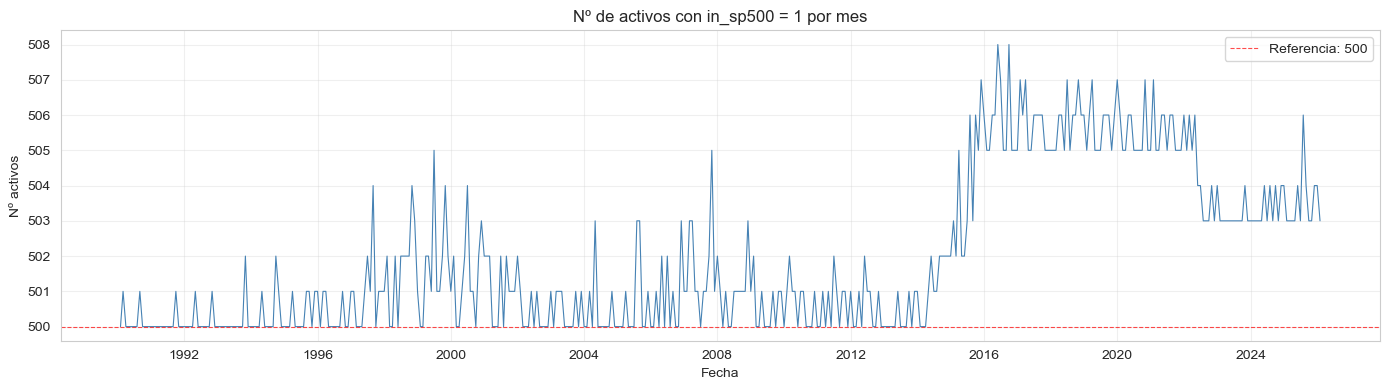

In [5]:
# Nº de activos con in_sp500=1 por mes (1990-2026)
membership_ts = dqa.membership_over_time()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(membership_ts.index, membership_ts.values, linewidth=0.8,
        color="steelblue")
ax.axhline(500, color="red", linestyle="--", linewidth=0.8, alpha=0.7,
           label="Referencia: 500")
ax.set_title("Nº de activos con in_sp500 = 1 por mes")
ax.set_xlabel("Fecha")
ax.set_ylabel("Nº activos")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Gap analysis: in_sp500=1 pero sin precio
gaps = dqa.gap_analysis(top_n=10)

Total gaps (in_sp500=1 & precio NaN): 0
Total observaciones in_sp500=1:       4,555,024
Porcentaje de gaps:                   0.0000%

No hay gaps — todos los activos in_sp500=1 tienen precio.


In [7]:
# Transiciones de membership: entradas y salidas del índice
df_transitions = dqa.membership_transitions(n_examples=10)

Activos con pertenencia NO consecutiva: 32

Ejemplos de pertenencia múltiple:
  AMD: 2 periodos → [(datetime.date(1990, 1, 2), datetime.date(2013, 9, 20)), (datetime.date(2017, 3, 20), datetime.date(2026, 1, 30))]
  CB: 2 periodos → [(datetime.date(2002, 1, 30), datetime.date(2008, 7, 17)), (datetime.date(2010, 7, 15), datetime.date(2026, 1, 30))]
  CBE-201211: 2 periodos → [(datetime.date(1990, 1, 2), datetime.date(2009, 9, 8)), (datetime.date(2011, 11, 23), datetime.date(2012, 11, 30))]
  COV-201501: 2 periodos → [(datetime.date(2007, 7, 2), datetime.date(2009, 6, 4)), (datetime.date(2011, 3, 1), datetime.date(2015, 1, 26))]
  DXC: 2 periodos → [(datetime.date(1990, 1, 2), datetime.date(2015, 11, 30)), (datetime.date(2017, 4, 4), datetime.date(2023, 10, 2))]
  EQT: 2 periodos → [(datetime.date(2008, 12, 19), datetime.date(2018, 11, 12)), (datetime.date(2022, 10, 3), datetime.date(2026, 1, 30))]
  FL-202509: 2 periodos → [(datetime.date(1990, 1, 2), datetime.date(1998, 12, 31)), (date

### Conclusiones Bloque 1

- El dataset contiene ~1289 tickers con datos desde 1990 hasta 2026.
- El número de activos en el S&P 500 ronda ~500 como se espera, con variaciones por recomposiciones del índice.
- Los gaps (membership=1 sin precio) son inexistentes.
- Se observan activos que entran y salen del índice en periodos no consecutivos, lo cual es esperable (ej: empresas que salen y vuelven a entrar al S&P 500). Por ejemplo es el caso de FMC Corporation (FMC) que sale en 2001 y vuelve a entrar en 2009, para salir de nuevo en 2025. En este análisis se ha tenido en cuenta el histórico completo del dataset, independientemente de el periodo de backesting.

## 3) Bloque 2 — Universo elegible y fechas de rebalanceo

Este bloque prepara los datos que alimentarán la estrategia de momentum en NB3.
Se ejecutan tres pasos en orden:

1. **Limpieza del universo de tickers** — El dataset contiene 1.289 símbolos, pero
   algunos representan la misma empresa (clases de acciones distintas o reorganizaciones
   corporativas). Se identifican y eliminan los duplicados para garantizar que cada
   empresa ocupe como máximo una posición en el ranking del top 20.

2. **Calendario de rebalanceo** — Se generan las fechas de rebalanceo mensuales
   (último día hábil de cada mes, desde enero 2015 hasta el fin del dataset).

3. **Universo elegible** — Para cada fecha de rebalanceo, se determina qué activos
   son elegibles: deben pertenecer al S&P 500 (`in_sp500 = 1`) y disponer de al
   menos 13 meses consecutivos de precios previos (necesario para calcular el
   momentum R_12 con lag de 1 mes sin look-ahead bias).

### 3.1) Detección y resolución de tickers duplicados

#### El problema

El dataset fuente (`sp500_history.parquet`) contiene 1.289 símbolos únicos.
Al analizar la columna `security_name` se detectan **dos categorías de duplicados**:

- **Clases de acciones simultáneas:** Algunas empresas cotizan con dos clases de
  acciones que conviven en el S&P 500 al mismo tiempo. Por ejemplo, Alphabet cotiza
  como GOOG (Class C) y GOOGL (Class A), Fox Corporation como FOX (Class B) y
  FOXA (Class A). Sin limpieza, ambos tickers podrían entrar en el top 20 del
  ranking de momentum, asignando un 10 % del capital a una sola empresa.

- **Duplicados corporativos históricos:** Empresas que cambiaron de ticker por
  fusiones, escisiones o reestructuraciones y aparecen con dos símbolos distintos
  pero el mismo `security_name` (e.g., Wells Fargo como WFC y WFC-199811).
  Aunque la mayoría no solapan en el periodo de backtesting, se limpian por
  consistencia del dataset.

#### Metodología

1. Se carga `sp500_history.parquet` y se extrae `security_name` y `volume` por ticker.
2. Se normaliza el nombre eliminando sufijos de clase ("Class A", "Class C",
   "Series A", etc.) mediante regex (expresiones regulares) para obtener un **nombre base** por empresa.
3. Se agrupan los tickers por nombre base. Los grupos con más de un ticker son duplicados.
4. **Criterio de desempate:** dentro de cada grupo, se conserva el ticker con mayor
   **volumen medio diario** (calculado solo sobre los días con `in_sp500 = 1`) La clase de acción con mayor volumen suele presentar una mayor liquidez y, por tanto, horquillas (bid-ask spreads) más estrechas. Los demás se eliminan.

#### Impacto esperado

- **16 tickers eliminados** del dataset global (de 1 289 a 1 273 columnas).
- De estos 16, solo **5 empresas** tienen impacto real durante el periodo de
  backtesting (2015-2026), ya que sus dos clases coexistían en el S&P 500 en las
  fechas de rebalanceo:
  - Alphabet (GOOG eliminado, se conserva GOOGL)
  - News Corporation (NWS eliminado, se conserva NWSA)
  - Twenty-First Century Fox (TFCF-201903 eliminado, se conserva TFCFA-201903)
  - Under Armour (UA eliminado, se conserva UAA)
  - Fox Corporation (FOX eliminado, se conserva FOXA)
- Los otros 11 duplicados son históricos (pre-2015 o sin solapamiento temporal)
  y no afectan al backtesting, pero se eliminan igualmente para mantener un
  dataset limpio.

In [8]:
class ShareClassResolver:
    """Detecta y resuelve empresas con múltiples clases de acciones
    en el universo del S&P 500.

    Retiene el ticker con mayor volumen medio diario por empresa.
    """

    _CLASS_SUFFIX = re.compile(
        r"\s*(Class\s+[A-Z]|Cl\s+[A-Z]|Series\s+[A-Z])\s*",
        re.IGNORECASE,
    )

    def __init__(self, history_path: Path):
        cols = ["symbol", "security_name", "volume", "in_sp500"]
        self._raw = pd.read_parquet(history_path, columns=cols)

    @staticmethod
    def _normalize_name(name: str) -> str:
        """Elimina sufijos de clase para obtener el nombre base."""
        return ShareClassResolver._CLASS_SUFFIX.sub(" ", str(name)).strip()

    def detect_duplicates(self) -> pd.DataFrame:
        """Identifica grupos de tickers que representan la misma empresa.

        Returns
        -------
        DataFrame con columnas [base_name, symbol, security_name, mean_volume]
        solo para empresas con >1 ticker.
        """
        latest = (
            self._raw
            .sort_values("symbol")
            .drop_duplicates(subset="symbol", keep="last")
            [["symbol", "security_name"]]
        )
        latest["base_name"] = latest["security_name"].apply(
            self._normalize_name
        )

        sp500_data = self._raw[self._raw["in_sp500"] == 1]
        mean_vol = (
            sp500_data
            .groupby("symbol")["volume"]
            .mean()
            .rename("mean_volume")
        )

        result = latest.merge(mean_vol, on="symbol", how="left")

        dup_names = (
            result.groupby("base_name")["symbol"]
            .count()
            .loc[lambda x: x > 1]
            .index
        )

        duplicates = (
            result[result["base_name"].isin(dup_names)]
            .sort_values(
                ["base_name", "mean_volume"], ascending=[True, False]
            )
            .reset_index(drop=True)
        )
        return duplicates

    def resolve(self) -> tuple[list[str], pd.DataFrame]:
        """Devuelve (tickers_a_eliminar, duplicates_df).

        Para cada grupo, se retiene el ticker con mayor volumen medio
        y se marcan los demás para eliminación.
        """
        duplicates = self.detect_duplicates()
        if duplicates.empty:
            return [], duplicates

        to_drop = []
        for _, group in duplicates.groupby("base_name"):
            to_drop.extend(group["symbol"].iloc[1:].tolist())

        return to_drop, duplicates

    def build_elimination_log(
        self, membership: pd.DataFrame, rebalance_dates: pd.DatetimeIndex
    ) -> pd.DataFrame:
        """Genera log temporal: qué tickers se eliminan en cada fecha.

        Solo incluye filas donde el ticker eliminado tenía in_sp500=1.
        """
        to_drop, duplicates = self.resolve()
        if not to_drop:
            return pd.DataFrame(
                columns=["fecha", "empresa", "ticker_eliminado",
                          "ticker_conservado"]
            )

        # Mapear cada ticker eliminado a su ticker conservado y base_name
        drop_map = {}
        for base_name, group in duplicates.groupby("base_name"):
            kept = group["symbol"].iloc[0]
            for sym in group["symbol"].iloc[1:]:
                drop_map[sym] = {"kept": kept, "base_name": base_name}

        records = []
        for reb_date in rebalance_dates:
            mb_idx = membership.index[membership.index <= reb_date]
            if len(mb_idx) == 0:
                continue
            mb_row = membership.loc[mb_idx[-1]]

            for dropped, info in drop_map.items():
                if dropped in mb_row.index and mb_row[dropped] == 1:
                    records.append({
                        "fecha": reb_date.date(),
                        "empresa": info["base_name"],
                        "ticker_eliminado": dropped,
                        "ticker_conservado": info["kept"],
                    })

        return pd.DataFrame(records)

    def summary(self, duplicates: pd.DataFrame) -> None:
        """Imprime resumen de las clases de acciones detectadas."""
        n_groups = duplicates["base_name"].nunique()
        n_tickers = len(duplicates)
        n_drop = n_tickers - n_groups

        print("=" * 60)
        print("CLASES DE ACCIONES DUPLICADAS")
        print("=" * 60)
        print(f"Empresas con multiples clases: {n_groups}")
        print(f"Tickers implicados:            {n_tickers}")
        print(f"Tickers a eliminar:            {n_drop}")
        print()

        for base_name, group in duplicates.groupby("base_name"):
            print(f"  {base_name}:")
            for i, (_, row) in enumerate(group.iterrows()):
                tag = "CONSERVAR" if i == 0 else "ELIMINAR"
                vol = row["mean_volume"]
                vol_str = f"{vol:>12,.0f}" if pd.notna(vol) else "         N/A"
                print(
                    f"    {row['symbol']:20s} | "
                    f"Vol medio: {vol_str} | "
                    f"{row['security_name']:45s} -> {tag}"
                )
            print()

In [9]:
# ── Detección de clases de acciones duplicadas ──
resolver = ShareClassResolver(DATA_DIR / "sp500_history.parquet")
tickers_to_drop, duplicates = resolver.resolve()

resolver.summary(duplicates)

CLASES DE ACCIONES DUPLICADAS
Empresas con multiples clases: 16
Tickers implicados:            32
Tickers a eliminar:            16

  Alphabet Inc Common:
    GOOGL                | Vol medio:   85,848,512 | Alphabet Inc Class A Common                   -> CONSERVAR
    GOOG                 | Vol medio:   30,823,764 | Alphabet Inc Class C Common                   -> ELIMINAR

  CIT Group Inc Common:
    CITGQ-200912         | Vol medio:    7,209,979 | CIT Group Inc Common                          -> CONSERVAR
    CIT-200106           | Vol medio:    1,515,671 | CIT Group Inc Class A Common                  -> ELIMINAR

  Dollar General Corp Common:
    DG                   | Vol medio:    3,288,488 | Dollar General Corp Common                    -> CONSERVAR
    DG-200707            | Vol medio:    2,051,225 | Dollar General Corp Common                    -> ELIMINAR

  Fox Corporation Common:
    FOXA                 | Vol medio:    3,988,131 | Fox Corporation Class A Common         

La tabla anterior muestra los 16 pares detectados. Se observan las dos categorías
anticipadas:

- **Clases de acciones activas** (relevantes para el backtesting): Alphabet,
  Fox Corp, News Corp, Under Armour y 21st Century Fox — empresas con dos
  tickers en el S&P 500 simultáneamente durante el periodo 2015-2026.
- **Duplicados corporativos** (sin impacto en el backtesting): empresas como
  Wells Fargo (WFC / WFC-199811), Dollar General (DG / DG-200707), etc.,
  cuyos períodos de pertenencia al índice no se solapan o lo hacen fuera
  del rango de backtesting.

En todos los casos se conserva el ticker con mayor volumen medio diario y se
elimina el otro. A continuación se aplica la limpieza sobre los DataFrames
wide (`closes`, `opens`, `membership`).

In [10]:
# ── Eliminar clases duplicadas de los DataFrames wide ──
tickers_to_drop = [t for t in tickers_to_drop if t in closes.columns]

# Guardar membership original para el log de eliminaciones
membership_original = membership.copy()

if tickers_to_drop:
    closes = closes.drop(columns=tickers_to_drop)
    opens = opens.drop(columns=tickers_to_drop)
    membership = membership.drop(columns=tickers_to_drop)

    print(f"Tickers eliminados ({len(tickers_to_drop)}): {tickers_to_drop}")
    print(f"\nNuevo shape:")
    print(f"  closes:     {closes.shape}")
    print(f"  opens:      {opens.shape}")
    print(f"  membership: {membership.shape}")
else:
    print("No se encontraron duplicados para eliminar.")

Tickers eliminados (16): ['GOOG', 'CIT-200106', 'DG-200707', 'FOX', 'GRL-199008', 'MNR-199809', 'MCK-199411', 'NWS', 'SK-200006', 'TWX-200101', 'TFCF-201903', 'USB-200102', 'UA', 'WB-200108', 'WMX-199807', 'WFC-199811']

Nuevo shape:
  closes:     (9087, 1273)
  opens:      (9087, 1273)
  membership: (9087, 1273)


### 3.2) Calendario de rebalanceo y log de eliminaciones

Se construyen las fechas de rebalanceo (último día hábil de cada mes) y, a
continuación, se genera un **log temporal** que registra en qué fechas de
rebalanceo cada ticker eliminado estaba efectivamente en el S&P 500.

Este log es la prueba de que la limpieza tiene impacto real: de los 16 tickers
eliminados globalmente, solo **5 empresas** tenían ambas clases activas durante
alguna fecha de rebalanceo del backtesting (2015-2026). El log detalla cada
ocurrencia para completa trazabilidad.

In [11]:
class RebalanceCalendar:
    """Construye calendario de rebalanceo y universo elegible."""

    def __init__(self, closes, membership):
        self.closes = closes
        self.membership = membership
        self.rebalance_dates = None
        self.eligible_universe = None  # DataFrame wide (date × tickers) con 1/0

    def build_rebalance_dates(self, start="2015-01", end=None):
        """Genera fechas de rebalanceo: último día hábil de cada mes.

        Las fechas teóricas (BM) se intersectan con las fechas reales
        del dataset para evitar fechas sin datos.
        """
        if end is None:
            end = self.closes.index.max()

        # Generar último día hábil de cada mes
        theoretical = pd.date_range(start=start, end=end, freq="BM")

        # Intersectar con fechas reales del dataset
        real_dates = self.closes.index
        matched = []
        for t_date in theoretical:
            # Buscar la fecha real más cercana (<=) a la teórica
            candidates = real_dates[real_dates <= t_date]
            if len(candidates) > 0:
                matched.append(candidates[-1])

        self.rebalance_dates = pd.DatetimeIndex(sorted(set(matched)))
        return self.rebalance_dates

    def build_eligible_universe(self, lookback_months=13):
        """Para cada fecha de rebalanceo, identifica activos elegibles.

        Criterios:
        1. in_sp500 = 1 en la fecha de rebalanceo
        2. Al menos `lookback_months` meses de precios no-NaN previos
           (necesario para R_12 con lag de 1 mes)
        """
        if self.rebalance_dates is None:
            raise ValueError("Ejecutar build_rebalance_dates() primero.")

        # Precomputar: precios mensuales (último día de cada mes)
        monthly_closes = self.closes.resample("ME").last()

        records = {}
        for reb_date in self.rebalance_dates:
            # 1) Activos en el S&P 500 en esta fecha
            # Usar la fila más cercana (<=) en membership
            mb_idx = self.membership.index[self.membership.index <= reb_date]
            if len(mb_idx) == 0:
                records[reb_date] = pd.Series(0, index=self.closes.columns)
                continue
            mb_row = self.membership.loc[mb_idx[-1]]
            in_sp500 = mb_row == 1

            # 2) Verificar lookback: al menos lookback_months de datos previos
            # Buscar meses anteriores en monthly_closes
            mc_prior = monthly_closes[monthly_closes.index < reb_date]
            if len(mc_prior) < lookback_months:
                has_history = pd.Series(False, index=self.closes.columns)
            else:
                window = mc_prior.iloc[-lookback_months:]
                # El activo es elegible si tiene precio en todos los meses
                has_history = window.notna().all()

            eligible = (in_sp500 & has_history).astype(int)
            records[reb_date] = eligible

        self.eligible_universe = pd.DataFrame(records).T
        self.eligible_universe.index.name = "date"
        return self.eligible_universe

    def universe_stats(self):
        """Estadísticas del tamaño del universo elegible por fecha."""
        if self.eligible_universe is None:
            raise ValueError("Ejecutar build_eligible_universe() primero.")

        sizes = self.eligible_universe.sum(axis=1)
        stats = {
            "Min activos elegibles": sizes.min(),
            "Max activos elegibles": sizes.max(),
            "Media activos elegibles": sizes.mean(),
            "Mediana": sizes.median(),
            "Fecha con min": sizes.idxmin().date(),
            "Fecha con max": sizes.idxmax().date(),
        }
        return pd.Series(stats)

In [12]:
# Construir fechas de rebalanceo: Enero 2015 hasta Enero 2026
cal = RebalanceCalendar(closes, membership)
reb_dates = cal.build_rebalance_dates(start="2015-01")

print(f"Total fechas de rebalanceo: {len(reb_dates)}")
print(f"\nPrimeras 5:  {[d.date() for d in reb_dates[:5]]}")
print(f"Últimas 5:   {[d.date() for d in reb_dates[-5:]]}")

Total fechas de rebalanceo: 133

Primeras 5:  [datetime.date(2015, 1, 30), datetime.date(2015, 2, 27), datetime.date(2015, 3, 31), datetime.date(2015, 4, 30), datetime.date(2015, 5, 29)]
Últimas 5:   [datetime.date(2025, 9, 30), datetime.date(2025, 10, 31), datetime.date(2025, 11, 28), datetime.date(2025, 12, 31), datetime.date(2026, 1, 30)]


C:\Users\diego\AppData\Local\Temp\ipykernel_13148\2961858069.py:20: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  theoretical = pd.date_range(start=start, end=end, freq="BM")


In [13]:
# ── Log temporal de eliminaciones por clase de acciones ──
elimination_log = resolver.build_elimination_log(
    membership_original, reb_dates
)

if not elimination_log.empty:
    print(f"Total eliminaciones en fechas de rebalanceo: {len(elimination_log)}")
    print(f"Empresas afectadas: "
          f"{elimination_log['empresa'].nunique()}")
    print()
    print(elimination_log.to_string(index=False))
else:
    print("No hay eliminaciones registradas.")

Total eliminaciones en fechas de rebalanceo: 457
Empresas afectadas: 5

     fecha                             empresa ticker_eliminado ticker_conservado
2015-01-30                 Alphabet Inc Common             GOOG             GOOGL
2015-02-27                 Alphabet Inc Common             GOOG             GOOGL
2015-03-31                 Alphabet Inc Common             GOOG             GOOGL
2015-04-30                 Alphabet Inc Common             GOOG             GOOGL
2015-05-29                 Alphabet Inc Common             GOOG             GOOGL
2015-06-30                 Alphabet Inc Common             GOOG             GOOGL
2015-07-31                 Alphabet Inc Common             GOOG             GOOGL
2015-08-31                 Alphabet Inc Common             GOOG             GOOGL
2015-09-30                 Alphabet Inc Common             GOOG             GOOGL
2015-09-30             News Corporation Common              NWS              NWSA
2015-09-30 Twenty-First Ce

### 3.3) Universo elegible por fecha de rebalanceo

Con los DataFrames ya limpios de duplicados, se construye el universo elegible.
Un activo es elegible en una fecha de rebalanceo si cumple dos condiciones:

1. `in_sp500 = 1` en esa fecha.
2. Dispone de al menos **13 meses consecutivos** de precios previos (lookback
   necesario para calcular R_12 con lag de 1 mes).

In [14]:
# Construir universo elegible
eligible = cal.build_eligible_universe(lookback_months=13)
print(f"eligible_universe shape: {eligible.shape}")

eligible_universe shape: (133, 1273)


Nos quedamos finalmente con 133 fechas de rebalanceo y 1273 activos (no se ha decsartado ninguno adicional a los duplicados por falta de histoico de 13 meses). Este universo elegible se exporta en formato wide (date × tickers) con 1/0 indicando elegibilidad, y se utilizará para filtrar los activos en el ranking de momentum en NB3.

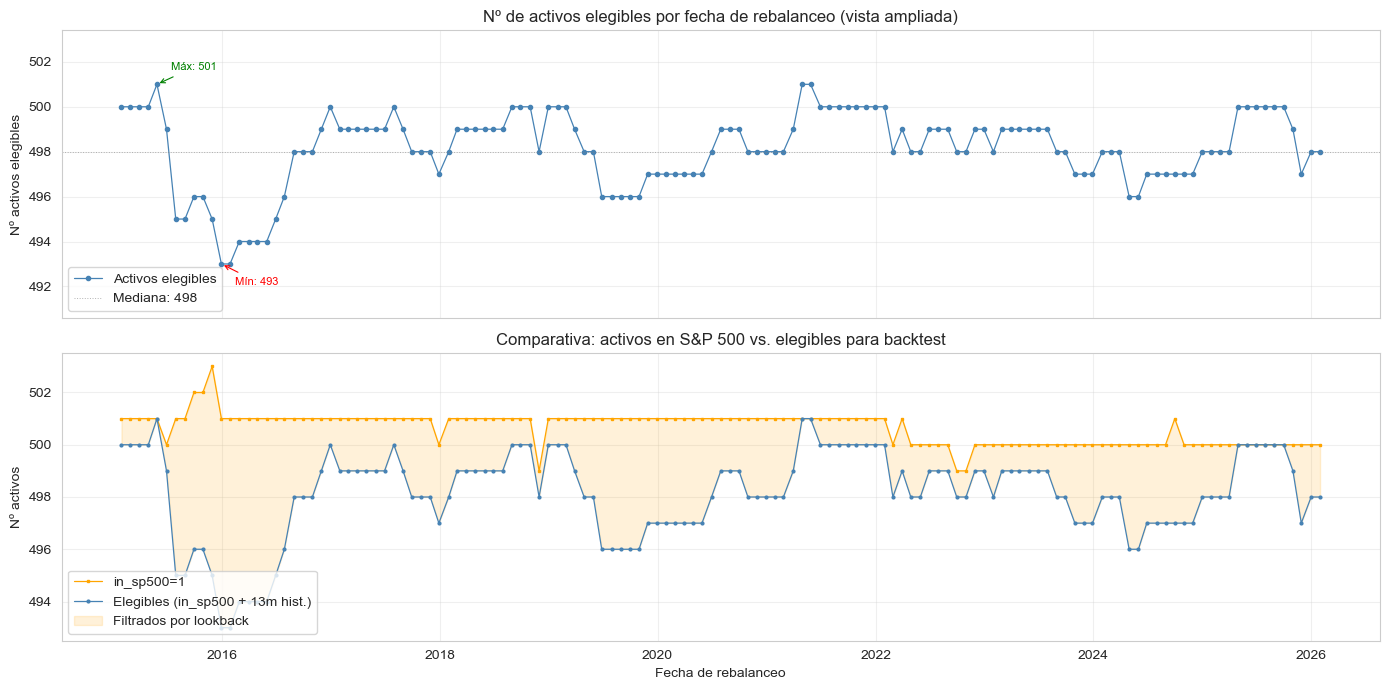

In [15]:
# Nº de activos elegibles por mes de rebalanceo
sizes = eligible.sum(axis=1)

# Get membership count for the same rebalance dates for comparison
membership_counts = membership.loc[sizes.index].sum(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ── Panel 1: Zoomed view of eligible universe ──
ax1.plot(sizes.index, sizes.values, linewidth=0.9, color="steelblue",
         marker="o", markersize=3, label="Activos elegibles")
ax1.set_ylabel("Nº activos elegibles")
ax1.set_title("Nº de activos elegibles por fecha de rebalanceo (vista ampliada)")
margin = (sizes.max() - sizes.min()) * 0.3
ax1.set_ylim(sizes.min() - max(margin, 1), sizes.max() + max(margin, 1))
ax1.axhline(sizes.median(), color="gray", linestyle=":", linewidth=0.7,
            alpha=0.6, label=f"Mediana: {sizes.median():.0f}")
# Annotate min and max
ax1.annotate(f"Mín: {sizes.min()}", xy=(sizes.idxmin(), sizes.min()),
             xytext=(10, -15), textcoords="offset points", fontsize=8,
             arrowprops=dict(arrowstyle="->", color="red", lw=0.8), color="red")
ax1.annotate(f"Máx: {sizes.max()}", xy=(sizes.idxmax(), sizes.max()),
             xytext=(10, 10), textcoords="offset points", fontsize=8,
             arrowprops=dict(arrowstyle="->", color="green", lw=0.8), color="green")
ax1.legend(loc="lower left")
ax1.grid(True, alpha=0.3)

# ── Panel 2: Eligible vs membership comparison ──
ax2.plot(sizes.index, membership_counts.values, linewidth=0.9,
         color="orange", marker="s", markersize=2, label="in_sp500=1")
ax2.plot(sizes.index, sizes.values, linewidth=0.9, color="steelblue",
         marker="o", markersize=2, label="Elegibles (in_sp500 + 13m hist.)")
ax2.fill_between(sizes.index, sizes.values, membership_counts.values,
                 alpha=0.15, color="orange", label="Filtrados por lookback")
ax2.set_xlabel("Fecha de rebalanceo")
ax2.set_ylabel("Nº activos")
ax2.set_title("Comparativa: activos en S&P 500 vs. elegibles para backtest")
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

En este apartado visualizamos la evolución del número de activos disponibles para el algoritmo en cada fecha de rebalanceo. Para que un activo sea considerado **elegible**, debe cumplir simultáneamente dos condiciones técnicas:
1. **Pertenencia al índice:** Formar parte del S&P 500 en la fecha del rebalanceo.
2. **Historial de datos (Lookback):** Tener información de precios disponible para los últimos 13 meses para poder calcular el Momentum de 12 y 6 meses con el decalaje (*lag*) de un mes requerido.

Interpretación de los Gráficos:

* **Vista Ampliada (Panel Superior):** Observamos que el universo elegible fluctúa en un rango estrecho entre **493 y 501 activos**. La mediana se sitúa en **498**, lo que indica que el filtro de los 13 meses de historial es relativamente poco restrictivo pero necesario para garantizar la integridad del cálculo de señales sin incurrir en *look-ahead bias*.
* **Comparativa vs. S&P 500 (Panel Inferior):** 
    * La línea naranja representa el número total de componentes del índice (`in_sp500=1`).
    * La línea azul muestra los activos que realmente podemos comprar tras aplicar el filtro de historial.
    * **Área sombreada (Filtrados por lookback):** Representa aquellos activos que, aunque forman parte del índice en ese momento (por ejemplo, tras una nueva incorporación o IPO reciente), son descartados por nuestra estrategia al no contar con los 13 meses de histórico necesarios para calcular su puntuación de Momentum.

Esta limpieza del universo es fundamental para garantizar que el backtesting sea **realista** y evitar el **sesgo de supervivencia**, ya que solo invertimos en activos que un gestor habría tenido disponibles y con datos suficientes en el momento real de la operación.

In [16]:
# Estadísticas del universo elegible
print("Estadísticas del universo elegible:")
print(cal.universe_stats().to_string())

Estadísticas del universo elegible:
Min activos elegibles             493
Max activos elegibles             501
Media activos elegibles    498.135338
Mediana                         498.0
Fecha con min              2015-12-31
Fecha con max              2015-05-29


In [17]:
# Sanity check: activos elegibles en 3 meses concretos
sample_dates = [reb_dates[0], reb_dates[len(reb_dates) // 2], reb_dates[-1]]

for d in sample_dates:
    tickers_elig = eligible.columns[eligible.loc[d] == 1].tolist()
    print(f"\n{d.date()} — {len(tickers_elig)} activos elegibles")
    print(f"  Primeros 15: {tickers_elig[:15]}")


2015-01-30 — 500 activos elegibles
  Primeros 15: ['A', 'AABA-201910', 'AAPL', 'ABBV', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'ADT-201604', 'AEE', 'AEP', 'AES']

2020-07-31 — 499 activos elegibles
  Primeros 15: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABMD-202212', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP']

2026-01-30 — 498 activos elegibles
  Primeros 15: ['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES']


### Conclusiones Bloque 2

**Limpieza de duplicados:**
- Se detectaron **16 pares de tickers duplicados** analizando la columna `security_name`
  del parquet fuente y normalizando los sufijos de clase de acciones.
- Se eliminaron 16 tickers (de 1 289 a 1 273 columnas), conservando en cada par
  el de mayor volumen medio diario.
- De estos 16, **solo 5 empresas afectan al backtesting** (2015-2026), ya que sus
  dos clases coexistían en el S&P 500 durante las fechas de rebalanceo: Alphabet
  (GOOG/GOOGL), News Corp (NWS/NWSA), 21st Century Fox (TFCF/TFCFA), Under Armour
  (UA/UAA) y Fox Corp (FOX/FOXA). En total, 457 eliminaciones en fechas de rebalanceo.
- Los otros 11 duplicados son corporativos históricos sin solapamiento en el periodo
  de backtesting.

**Universo elegible:**
- Se generan **133 fechas de rebalanceo** mensuales (Ene 2015 → Ene 2026).
- El universo elegible oscila entre ~493 y ~501 activos por fecha, muy por encima
  del mínimo de 20 necesarios para seleccionar el top 20.
- El criterio de 13 meses de lookback filtra correctamente activos sin historia
  suficiente para calcular el momentum R_12.

## 4) Bloque 3 — Benchmark SPY

Análisis del SPY en el periodo de backtest (2015+) como referencia para la comparativa posterior.

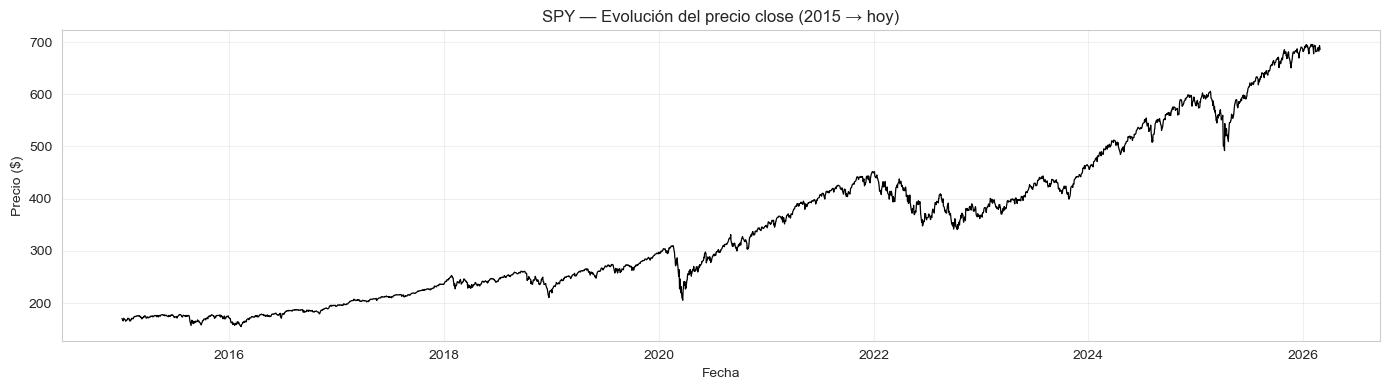

In [18]:
# Filtrar SPY al periodo de backtest
spy_bt = spy.loc["2015-01-01":]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spy_bt.index, spy_bt["close"], linewidth=0.9, color="black")
ax.set_title("SPY — Evolución del precio close (2015 → hoy)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio ($)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Estadísticas descriptivas del SPY en el periodo de backtest
spy_returns = spy_bt["close"].pct_change().dropna()
n_years = len(spy_returns) / 252

cumulative = (1 + spy_returns).cumprod()
total_return = cumulative.iloc[-1] - 1
cagr = cumulative.iloc[-1] ** (1 / n_years) - 1
vol_annual = spy_returns.std() * np.sqrt(252)
sharpe = (spy_returns.mean() * 252) / vol_annual
drawdown = (cumulative / cumulative.cummax() - 1)
max_dd = drawdown.min()

spy_stats = pd.DataFrame({
    "Métrica": ["Retorno total", "CAGR", "Volatilidad anualizada",
                "Sharpe Ratio", "Max Drawdown", "Periodo (años)"],
    "Valor": [f"{total_return:.2%}", f"{cagr:.2%}", f"{vol_annual:.2%}",
              f"{sharpe:.2f}", f"{max_dd:.2%}", f"{n_years:.1f}"],
})
spy_stats

,Métrica,Valor
0,Retorno total,302.13%
1,CAGR,13.32%
2,Volatilidad anualizada,17.72%
3,Sharpe Ratio,0.79
4,Max Drawdown,-33.72%
5,Periodo (años),11.1


### Conclusiones Bloque 3

- SPY sirve como benchmark buy-and-hold del S&P 500 para comparar con la estrategia de momentum.
- Las métricas del SPY en el periodo 2015-2026 muestran el rendimiento que una estrategia pasiva habría obtenido.

## 5) Exportar outputs para NB3+

Se guardan las fechas de rebalanceo y el universo elegible en `/data/` para consumo directo por los notebooks posteriores.

In [20]:
# Guardar fechas de rebalanceo
reb_path = DATA_DIR / "rebalance_dates.csv"
pd.DataFrame({"date": reb_dates}).to_csv(reb_path, index=False)

# Guardar universo elegible
elig_path = DATA_DIR / "eligible_universe.parquet"
eligible.to_parquet(elig_path)

# Re-exportar closes, opens y membership limpios (sin clases duplicadas)
closes.to_parquet(DATA_DIR / "closes.parquet")
opens.to_parquet(DATA_DIR / "opens.parquet")
membership.to_parquet(DATA_DIR / "sp500_membership.parquet")

# Exportar log de eliminaciones
log_path = DATA_DIR / "share_class_log.csv"
elimination_log.to_csv(log_path, index=False)

print("Archivos exportados:")
for path in [reb_path, elig_path, log_path]:
    size_kb = path.stat().st_size / 1e3
    print(f"  {path.name:35s} ({size_kb:.1f} KB)")

print("\nParquets wide re-exportados (sin duplicados):")
for name, df in [("closes", closes), ("opens", opens),
                 ("membership", membership)]:
    print(f"  {name:15s} {df.shape}")

Archivos exportados:
  rebalance_dates.csv                 (1.6 KB)
  eligible_universe.parquet           (699.2 KB)
  share_class_log.csv                 (21.3 KB)

Parquets wide re-exportados (sin duplicados):
  closes          (9087, 1273)
  opens           (9087, 1273)
  membership      (9087, 1273)


In [21]:
# Validación final: confirmar que todos los ficheros necesarios existen
required_files = [
    "closes.parquet", "opens.parquet", "sp500_membership.parquet",
    "spy.parquet", "rebalance_dates.csv", "eligible_universe.parquet",
    "share_class_log.csv",
]

print("Validación final de archivos en /data/:")
all_ok = True
for fname in required_files:
    path = DATA_DIR / fname
    exists = path.exists()
    size = f"{path.stat().st_size / 1e3:.1f} KB" if exists else "NO ENCONTRADO"
    status = "OK" if exists else "FALTA"
    print(f"  [{status}] {fname:35s} {size}")
    if not exists:
        all_ok = False

print(f"\n{'Todos los archivos presentes.' if all_ok else 'FALTAN ARCHIVOS.'}")

Validación final de archivos en /data/:
  [OK] closes.parquet                      33294.5 KB
  [OK] opens.parquet                       32945.2 KB
  [OK] sp500_membership.parquet            813.2 KB
  [OK] spy.parquet                         218.6 KB
  [OK] rebalance_dates.csv                 1.6 KB
  [OK] eligible_universe.parquet           699.2 KB
  [OK] share_class_log.csv                 21.3 KB

Todos los archivos presentes.
